# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Anastacia Oliynyk

**Date:** 9/2/26

In [35]:
# Your Phase 1 solution to the problem goes here.
from google.colab import files
uploaded = files.upload()

Saving airbnb_hw.csv to airbnb_hw (1).csv


Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion:
 count       30478.0
mean     163.589737
std      197.785454
min            10.0
25%            80.0
50%           125.0
75%           195.0
max         10000.0
Name: Price, dtype: Float64 

Total missings: 0


<Axes: >

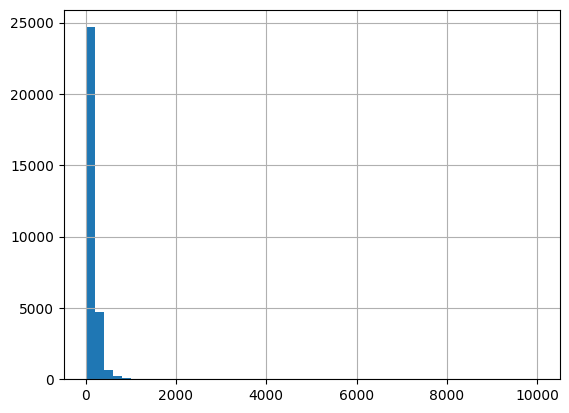

In [36]:
#1.1

import pandas as pd

df = pd.read_csv('airbnb_hw.csv')

var = 'Price'

print('Before coercion:\n', df[var].describe(), '\n')

df[var] = (
    df[var]
    .astype('string')                     #make values strings
    .str.replace(',', '', regex=False)    #removes comma from the text
    .str.strip()                          #removes extra spaces
)

df[var] = pd.to_numeric(df[var], errors='coerce')   #convert into numbers

print('After coercion:\n', df[var].describe(), '\n')

print('Total missings:', df[var].isna().sum())

df[var].hist(bins=50)

# The Price variable was stored as a string because prices over $999 contained commas, like 1,112.
# I removed the commas and extra space, then converted Price to a numeric variable.
# After cleaning, there were 0 missing values.

In [37]:
from google.colab import files
uploaded = files.upload()

Saving mn_police_use_of_force.csv to mn_police_use_of_force (1).csv


In [38]:
#1.2

import pandas as pd

df = pd.read_csv('mn_police_use_of_force.csv')
var = 'subject_injury'

print(df[var].unique(), '\n')
print(df[var].value_counts(dropna=False), '\n')

df[var] = (
    df[var]
    .astype('string')
    .str.strip()
    .str.title()
)

print(df[var].value_counts(dropna=False), '\n')

missing_prop = df[var].isna().mean()

missing_by_force = (
    df[var]
    .isna()
    .groupby(df['force_type'])
    .mean() * 100
)

print(missing_by_force.sort_values(ascending=False))

print('Proportion missing:', missing_prop)
print('Percent missing:', missing_prop * 100)

pd.crosstab(df[var], df['force_type'], dropna=False)

#About 76.2% of the subject_injury values are missing.
#this is a concern because more than three-fourths of the observations
#do not have injury information. i kept these values as missing rather
#than changing them to no, since a missing value doesnt always mean no injury happened.
#the crosstab shows a pattern in the missing data. some force types have much
#more missing injury info than others. for ex, less lethal and maximal restraint technique
#have all missing values while gun point display has much less. this suggests
#missingness might be related to the type of force used

[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

subject_injury
<NA>    9848
Yes     1631
No      1446
Name: count, dtype: Int64 

force_type
Less Lethal                    100.000000
Maximal Restraint Technique    100.000000
Chemical Irritant               89.202762
Taser                           75.363428
Bodily Force                    74.772004
Baton                           50.000000
Improvised Weapon               50.000000
Police K9 Bite                  40.259740
Gun Point Display               25.961538
Firearm                          0.000000
Less Lethal Projectile           0.000000
Name: subject_injury, dtype: float64
Proportion missing: 0.7619342359767892
Percent missing: 76.19342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
<NA>,2,7051,1421,0,27,74,87,0,170,31,985


In [39]:
from google.colab import files
uploaded = files.upload()

Saving GSAF5.xls to GSAF5 (1).xls


In [40]:
#2.1

import pandas as pd

df = pd.read_excel('GSAF5.xls')

df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
#2.2

empty_cols = df.columns[df.isna().all()]
print('Empty columns:', empty_cols)
df = df.dropna(axis=1, how='all')
print(df.columns)

# No completely empty columns were found, so no columns were removed.

Empty columns: Index([], dtype='object')
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22', 'Age_clean',
       'Sex_clean', 'Type_clean'],
      dtype='object')


Before cleaning:
 count    6986.000000
mean     1972.308474
std        60.634293
min         5.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

After cleaning: 
 count    6986.000000
mean     1972.308474
std        60.634293
min         5.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

Minimum year: 5.0
Maximum year: 2026.0


<Axes: xlabel='Year'>

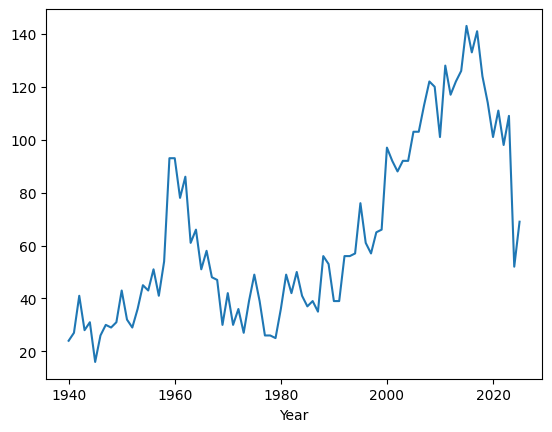

In [56]:
#2.3

var = 'Year'
print('Before cleaning:\n', df[var].describe(), '\n')
df[var]=pd.to_numeric(df[var], errors='coerce')

df.loc[df[var] <= 0, var] = pd.NA

print('After cleaning: \n', df[var].describe(), '\n')
print('Minimum year:', df[var].min())
print('Maximum year:', df[var].max())

df_recent = df[
    (df[var] >= 1940) &
    (df[var] < 2026)
].copy()
attacks_by_year = df_recent.groupby(var).size()
attacks_by_year.plot()

#attacks are generally increasing over time especially from around 1980s-mid 2010s. there is a noticeable decline in recent years and are not remaining constant, but the overall pattern since 1940 is increasing

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


<Axes: >

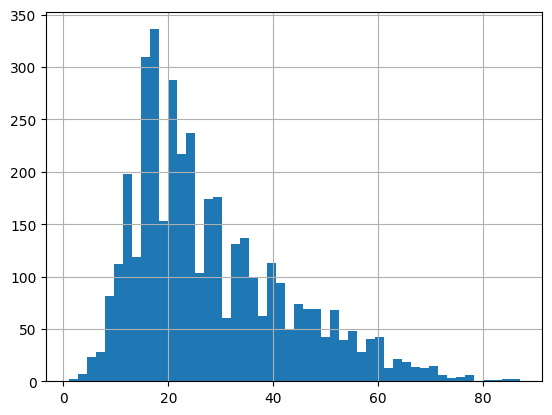

In [57]:
#2.4

var = 'Age'
print(df[var].unique(),'\n')
df['Age_clean']=(
    df[var]
    .astype('string')
    .str.strip()
)

df['Age_clean'] = pd.to_numeric(df['Age_clean'], errors='coerce')

df['Age_clean'] = df['Age_clean'].where(
    df['Age_clean'].between(1, 120)
)

print(df['Age_clean'].describe())
print('Total missing ages:', df['Age_clean'].isna().sum())
df['Age_clean'].hist(bins=50)

In [58]:
#2.5

print(df['Sex'].value_counts(dropna=False))
df['Sex_clean']=(
    df['Sex']
    .astype('string')
    .str.strip()
    .str.upper()
)

df['Sex_clean'] = df['Sex_clean'].where(
    df['Sex_clean'].isin(['M','F'])
)

known_sex = df['Sex_clean'].notna().sum()
male_count = (df['Sex_clean'] == 'M').sum()

male_prop = male_count / known_sex

print('Known M/F observations:', known_sex)
print('Male observations:', male_count)
print('Proportion male:', male_prop)
print('Percent male:', round(male_prop * 100, 1))

Sex
M        5704
F         816
NaN       578
M           7
?           2
N           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64
Known M/F observations: 6531
Male observations: 5713
Proportion male: 0.8747511866482928
Percent male: 87.5


In [45]:
#2.6

print(df['Type'].value_counts(dropna=False))

df['Type_clean'] = (
    df['Type']
    .astype('string')
    .str.strip()
    .str.title()
)

df['Type_clean'] = df['Type_clean'].where(
    df['Type_clean'].isin(['Provoked', 'Unprovoked']),
    'Unknown'
)

print(df['Type_clean'].value_counts(dropna=False))

unprovoked_prop = (df['Type_clean'] == 'Unprovoked').mean()

print('Proportion unprovoked:', unprovoked_prop)
print('Percent unprovoked:', round(unprovoked_prop * 100, 1))

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
NaN                      18
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: Int64
Proportion unprovoked: 0.7394969790642124
Percent unprovoked: 73.9


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 5e88adb

---


- **AI tool and model used:** Chatgpt GPT-5.6 Sol

### *Prompts used

1. Review my Phase 1 code for this notebook and tell me what I should improve for Phase 2. Focus on whether my data cleaning choices and interpretations are correct.
2. Go through each section of my Phase 1 solution and tell me specifically what I should change, keep, or clarify in my revised Phase 2 solution.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Make the missingness analysis for subject_injury clearer by calculating the percentage missing within each force_type, rather than relying only on the crosstab counts.
2. Keep missing subject_injury values as missing instead of changing them to "No", because a missing value does not necessarily mean that no injury occurred.
3. Treat invalid year values such as 0 as missing before analyzing the shark attack data, and avoid interpreting the incomplete 2026 data as evidence of a recent decline.
4. Keep the Age cleaning conservative by converting exact numeric ages to numbers while leaving ranges, multiple ages, and vague descriptions as missing instead of guessing a value.
5. Make the calculation of the proportion of male victims more explicit by using only observations with a valid M or F value in the denominator.
6. Keep the Type cleaning method that maps Provoked and Unprovoked to those categories and assigns every other value to Unknown, while making the final calculation and explanation clearer.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | The original crosstab showed that missing injury information differed by force type, but percentages make the pattern easier to compare because the force types have different numbers of observations. |
| 2 | Accept | Missing injury values should not be interpreted as "No". Keeping them missing avoids making an assumption that is not supported by the data.|
| 3 | Accept | The minimum year in Phase 1 was 0, which is not a meaningful year for this analysis. Also, 2026 is not a complete year, so its lower number of attacks should not be used to conclude that attacks are currently declining.|
| 4 | Accept | The Age variable contains entries such as "20's", "45 and 15", "18 or 20", and "Middle age". Assigning a single age to these observations would require guessing, so they are left missing.|
| 5 | Accept | The Phase 1 calculation already produced about 87.5% male, but explicitly using the number of known M/F observations as the denominator makes the calculation easier to understand.|
| 6 | Accept | The original Type cleaning correctly standardized capitalization and mapped all categories other than Provoked and Unprovoked to Unknown. This approach matches the question, so only minor clarification is needed. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [46]:
# Your Phase 2 solution to the problem goes here.

import pandas as pd
import matplotlib.pyplot as plt

Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion:
 count       30478.0
mean     163.589737
std      197.785454
min            10.0
25%            80.0
50%           125.0
75%           195.0
max         10000.0
Name: Price, dtype: Float64 

Total missings: 0


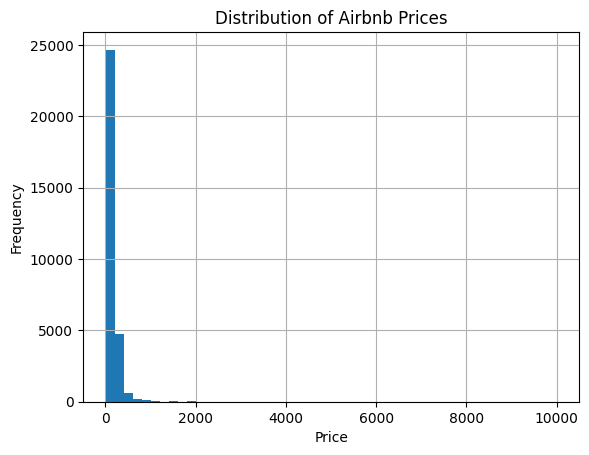

In [47]:
# 1.1

df_airbnb = pd.read_csv('airbnb_hw.csv')

var = 'Price'

print('Before coercion:\n', df_airbnb[var].describe(), '\n')

df_airbnb[var] = (
    df_airbnb[var]
    .astype('string')
    .str.replace(',', '', regex=False)
    .str.strip()
)

df_airbnb[var] = pd.to_numeric(df_airbnb[var], errors='coerce')

print('After coercion:\n', df_airbnb[var].describe(), '\n')
print('Total missings:', df_airbnb[var].isna().sum())

df_airbnb[var].hist(bins=50)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# The Price variable was stored as text because prices over $999 contained
# commas, such as 1,112. I removed the commas and extra whitespace and then
# converted Price to numeric. After cleaning, there were 0 missing values.

In [48]:
# 1.2

df_police = pd.read_csv('mn_police_use_of_force.csv')

var = 'subject_injury'

print(df_police[var].unique(), '\n')
print(df_police[var].value_counts(dropna=False), '\n')

df_police[var] = (
    df_police[var]
    .astype('string')
    .str.strip()
    .str.title()
)

print(df_police[var].value_counts(dropna=False), '\n')

missing_prop = df_police[var].isna().mean()

print('Proportion missing:', missing_prop)
print('Percent missing:', round(missing_prop * 100, 1))

crosstab = pd.crosstab(
    df_police[var],
    df_police['force_type'],
    dropna=False
)

print('\nCrosstab:')
display(crosstab)

missing_by_force = (
    df_police[var]
    .isna()
    .groupby(df_police['force_type'])
    .mean() * 100
)

print('\nPercent missing by force type:')
print(missing_by_force.sort_values(ascending=False))

# About 76.2% of the subject_injury values are missing. This is a concern
# because more than three-fourths of the observations do not contain injury
# information. I kept these observations missing rather than changing them
# to "No" because missing information does not necessarily mean that no
# injury occurred. Missingness also varies by force type, suggesting that
# the missing data are not distributed evenly across force types.

[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

subject_injury
<NA>    9848
Yes     1631
No      1446
Name: count, dtype: Int64 

Proportion missing: 0.7619342359767892
Percent missing: 76.2

Crosstab:


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
<NA>,2,7051,1421,0,27,74,87,0,170,31,985



Percent missing by force type:
force_type
Less Lethal                    100.000000
Maximal Restraint Technique    100.000000
Chemical Irritant               89.202762
Taser                           75.363428
Bodily Force                    74.772004
Baton                           50.000000
Improvised Weapon               50.000000
Police K9 Bite                  40.259740
Gun Point Display               25.961538
Firearm                          0.000000
Less Lethal Projectile           0.000000
Name: subject_injury, dtype: float64


In [49]:
# 2.1

df_shark = pd.read_excel('GSAF5.xls')
df_shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
# 2.2

empty_cols = df_shark.columns[df_shark.isna().all()]
print('Empty columns:', empty_cols)
df_shark = df_shark.dropna(axis=1, how='all')
print(df_shark.columns)

# No completely empty columns were identified in this version of the dataset,
# so no columns were removed by this step.

Empty columns: Index([], dtype='object')
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


Before cleaning:
 count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

After cleaning:
 count    6986.000000
mean     1972.308474
std        60.634293
min         5.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

Minimum year: 5.0
Maximum year: 2026.0


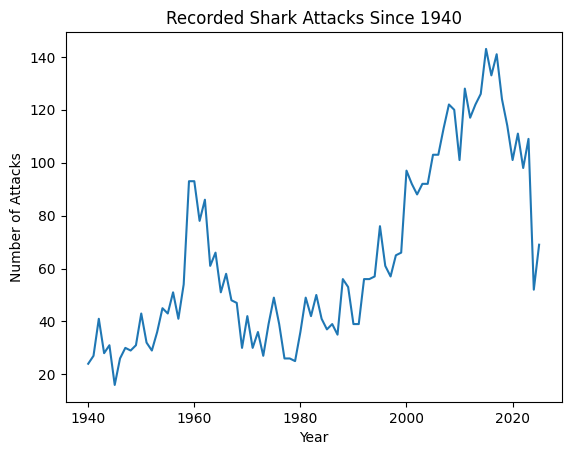

In [51]:
# 2.3

var = 'Year'
print('Before cleaning:\n', df_shark[var].describe(), '\n')
df_shark[var] = pd.to_numeric(df_shark[var], errors='coerce')

# A year of 0 is not a meaningful year, so treat it as missing.
df_shark.loc[df_shark[var] <= 0, var] = pd.NA

print('After cleaning:\n', df_shark[var].describe(), '\n')
print('Minimum year:', df_shark[var].min())
print('Maximum year:', df_shark[var].max())

df_recent = df_shark[
    (df_shark[var] >= 1940) &
    (df_shark[var] < 2026)
].copy()

attacks_by_year = df_recent.groupby(var).size()

attacks_by_year.plot()
plt.title('Recorded Shark Attacks Since 1940')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()

# Recorded shark attacks generally increase over time, especially from about
# the 1980s through the early 2000s and 2010s. I excluded 2026 from the trend
# graph because it is an incomplete year, so comparing its current count with
# complete previous years could create a misleading appearance of decline.
# Overall, the pattern since 1940 is increasing rather than constant.

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


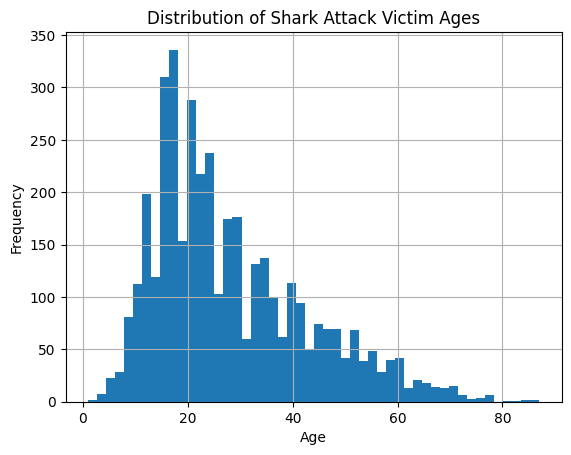

In [52]:
# 2.4

var = 'Age'
print(df_shark[var].unique(), '\n')
df_shark['Age_clean'] = (
    df_shark[var]
    .astype('string')
    .str.strip()
)

df_shark['Age_clean'] = pd.to_numeric(
    df_shark['Age_clean'],
    errors='coerce'
)

# Keep only plausible positive ages.

df_shark['Age_clean'] = df_shark['Age_clean'].where(
    df_shark['Age_clean'].between(1, 120)
)

print(df_shark['Age_clean'].describe())
print('Total missing ages:', df_shark['Age_clean'].isna().sum())

df_shark['Age_clean'].hist(bins=50)
plt.title('Distribution of Shark Attack Victim Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Exact numeric ages were converted to numbers. Ambiguous values such as
# ranges, multiple ages, decades, and descriptions were left missing rather
# than assigning an age that was not directly supported by the data.

In [53]:
# 2.5

print(df_shark['Sex'].value_counts(dropna=False))

df_shark['Sex_clean'] = (
    df_shark['Sex']
    .astype('string')
    .str.strip()
    .str.upper()
)

df_shark['Sex_clean'] = df_shark['Sex_clean'].where(
    df_shark['Sex_clean'].isin(['M', 'F'])
)

known_sex = df_shark['Sex_clean'].notna().sum()
male_count = (df_shark['Sex_clean'] == 'M').sum()

male_prop = male_count / known_sex

print('Known M/F observations:', known_sex)
print('Male observations:', male_count)
print('Proportion male:', male_prop)
print('Percent male:', round(male_prop * 100, 1))

# About 87.5% of victims with a known M/F sex value are male.

Sex
M        5704
F         816
NaN       578
M           7
?           2
N           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64
Known M/F observations: 6531
Male observations: 5713
Proportion male: 0.8747511866482928
Percent male: 87.5


In [54]:
# 2.6

print(df_shark['Type'].value_counts(dropna=False))

df_shark['Type_clean'] = (
    df_shark['Type']
    .astype('string')
    .str.strip()
    .str.title()
)

df_shark['Type_clean'] = df_shark['Type_clean'].where(
    df_shark['Type_clean'].isin(['Provoked', 'Unprovoked']),
    'Unknown'
)

print(df_shark['Type_clean'].value_counts(dropna=False))

unprovoked_prop = (
    df_shark['Type_clean'] == 'Unprovoked'
).mean()

print('Proportion unprovoked:', unprovoked_prop)
print('Percent unprovoked:', round(unprovoked_prop * 100, 1))

# After cleaning, Type contains only Provoked, Unprovoked, and Unknown.
# About 73.9% of all attacks are classified as Unprovoked.

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
NaN                      18
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: Int64
Proportion unprovoked: 0.7394969790642124
Percent unprovoked: 73.9


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The biggest improvement I made was making the missingness analysis for subject_injury clearer by comparing missing percentages across force_type. i also cleaned year more carefully by treating 0 as invalid and accounting for 2026 being incomplete. another improvement was clarifying why ambiguous age values should stay missing instead of being guessed as well as making the male proportion denominator clearer.

some ai suggestions were not necessary like the original price and type cleaning were already correct and there was no reason to completely rewrite the section. ai also initially suggested dropping unnamed shark-data columns without first proving they contained no meaningful data.

i verified teh solution by reruning the code and checking everything works correctly and looks right. i also checked that important final results like 87.5% male and 73.9% unprovoked stayed consistent.

a remaining concern is that the shark data set still contains some messy/ambiguous age values, so converting only clear numeric ages means some information is list.